<a href="https://colab.research.google.com/github/allenphos/ML-course-ua-/blob/main/Copy_of_HW_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D1%96%D1%97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


# **Завдання 1**.
Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.datasets import load_wine, load_iris
import seaborn as sns

pd.set_option('float_format', '{:.2f}'.format)

In [3]:
df = pd.read_csv('drive/MyDrive/Colab Notebooks/data/marketing_campaign.csv', sep='\t')
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.00,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.00,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.00,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.00,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.00,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.00,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.00,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.00,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.00,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.00,2240.00,2216.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,...,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00
mean,5592.16,1968.81,52247.25,0.44,0.51,49.11,303.94,26.30,166.95,37.53,...,5.32,0.07,0.07,0.07,0.06,0.01,0.01,3.00,11.00,0.15
std,3246.66,11.98,25173.08,0.54,0.54,28.96,336.60,39.77,225.72,54.63,...,2.43,0.26,0.26,0.26,0.25,0.11,0.10,0.00,0.00,0.36
min,0.00,1893.00,1730.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,11.00,0.00
25%,2828.25,1959.00,35303.00,0.00,0.00,24.00,23.75,1.00,16.00,3.00,...,3.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,11.00,0.00
50%,5458.50,1970.00,51381.50,0.00,0.00,49.00,173.50,8.00,67.00,12.00,...,6.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,11.00,0.00
75%,8427.75,1977.00,68522.00,1.00,1.00,74.00,504.25,33.00,232.00,50.00,...,7.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,11.00,0.00
max,11191.00,1996.00,666666.00,2.00,2.00,99.00,1493.00,199.00,1725.00,259.00,...,20.00,1.00,1.00,1.00,1.00,1.00,1.00,3.00,11.00,1.00


In [6]:
df.isna().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [7]:
print(df["Income"].isna().mean() * 100)  # Percentage of missing values

1.0714285714285714


In [8]:
Q1 = df["Income"].quantile(0.25)
Q3 = df["Income"].quantile(0.95)
IQR = Q3 - Q1
print(IQR)

Min_value2 = (Q1 - 1.5 * IQR)
Max_value2 = (Q3 + 1.5 * IQR)
print("Minimum value up to which there are outliers: {}".format(Min_value2))
print("Maximum value after which there are outliers: {}".format(Max_value2))

48827.0
Minimum value up to which there are outliers: -37937.5
Maximum value after which there are outliers: 157370.5


2240 rows × 29 columns

3 categorical columns: Education, Marital_Status, Dt_Customer

25 numerical

Income	24 NaN (1%)

Outliers

#**Завдання 2.**
Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

Для невеликої частки пропущених значень в колонці з залишками краще підійде заповнення медіаною.

In [9]:
df['Income'].fillna(df['Income'].median(), inplace=True)

<ipython-input-9-b0f8a841459e>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].median(), inplace=True)


# **Завдання 3.**
У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [10]:
df['Marital_Status'].value_counts()

,count
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Alone,3
Absurd,2
YOLO,2


In [11]:
df['Education'].value_counts()

,count
Education,
Graduation,1127
PhD,486
Master,370
2n Cycle,203
Basic,54


In [12]:
df['Dt_Customer'] = pd.to_datetime(df["Dt_Customer"], format='%d-%m-%Y') # Дата реєстрації клієнта у компанії

For preserving order information OrdinalEncoder for Education

In [13]:
from sklearn.preprocessing import OrdinalEncoder

education_categories = ['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD']

encoder = OrdinalEncoder(categories=[education_categories])

# Fit and transform the 'Education' column
df['Education_Encoded'] = encoder.fit_transform(df[['Education']])

# Drop the original 'Education' column (optional)
df = df.drop('Education', axis=1)

One-hot encoding for Marital_Status

In [14]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')  # sparse=False for a dense array

encoded_data = encoder.fit_transform(df[['Marital_Status']])

feature_names = encoder.get_feature_names_out(['Marital_Status'])

# Create a DataFrame from the encoded data
encoded_df = pd.DataFrame(encoded_data, columns=feature_names, index=df.index)

# Concatenate the encoded DataFrame with the original DataFrame
df = pd.concat([df, encoded_df], axis=1)

# Drop the original 'Marital_Status' column
df = df.drop('Marital_Status', axis=1)

In [15]:
from datetime import datetime

# Calculate customer tenure in days
df['CustomerTenure'] = (datetime.now() - df['Dt_Customer']).dt.days

# Extract the year the customer joined
df['YearJoined'] = df['Dt_Customer'].dt.year

# Extract the month the customer joined
df['MonthJoined'] = df['Dt_Customer'].dt.month

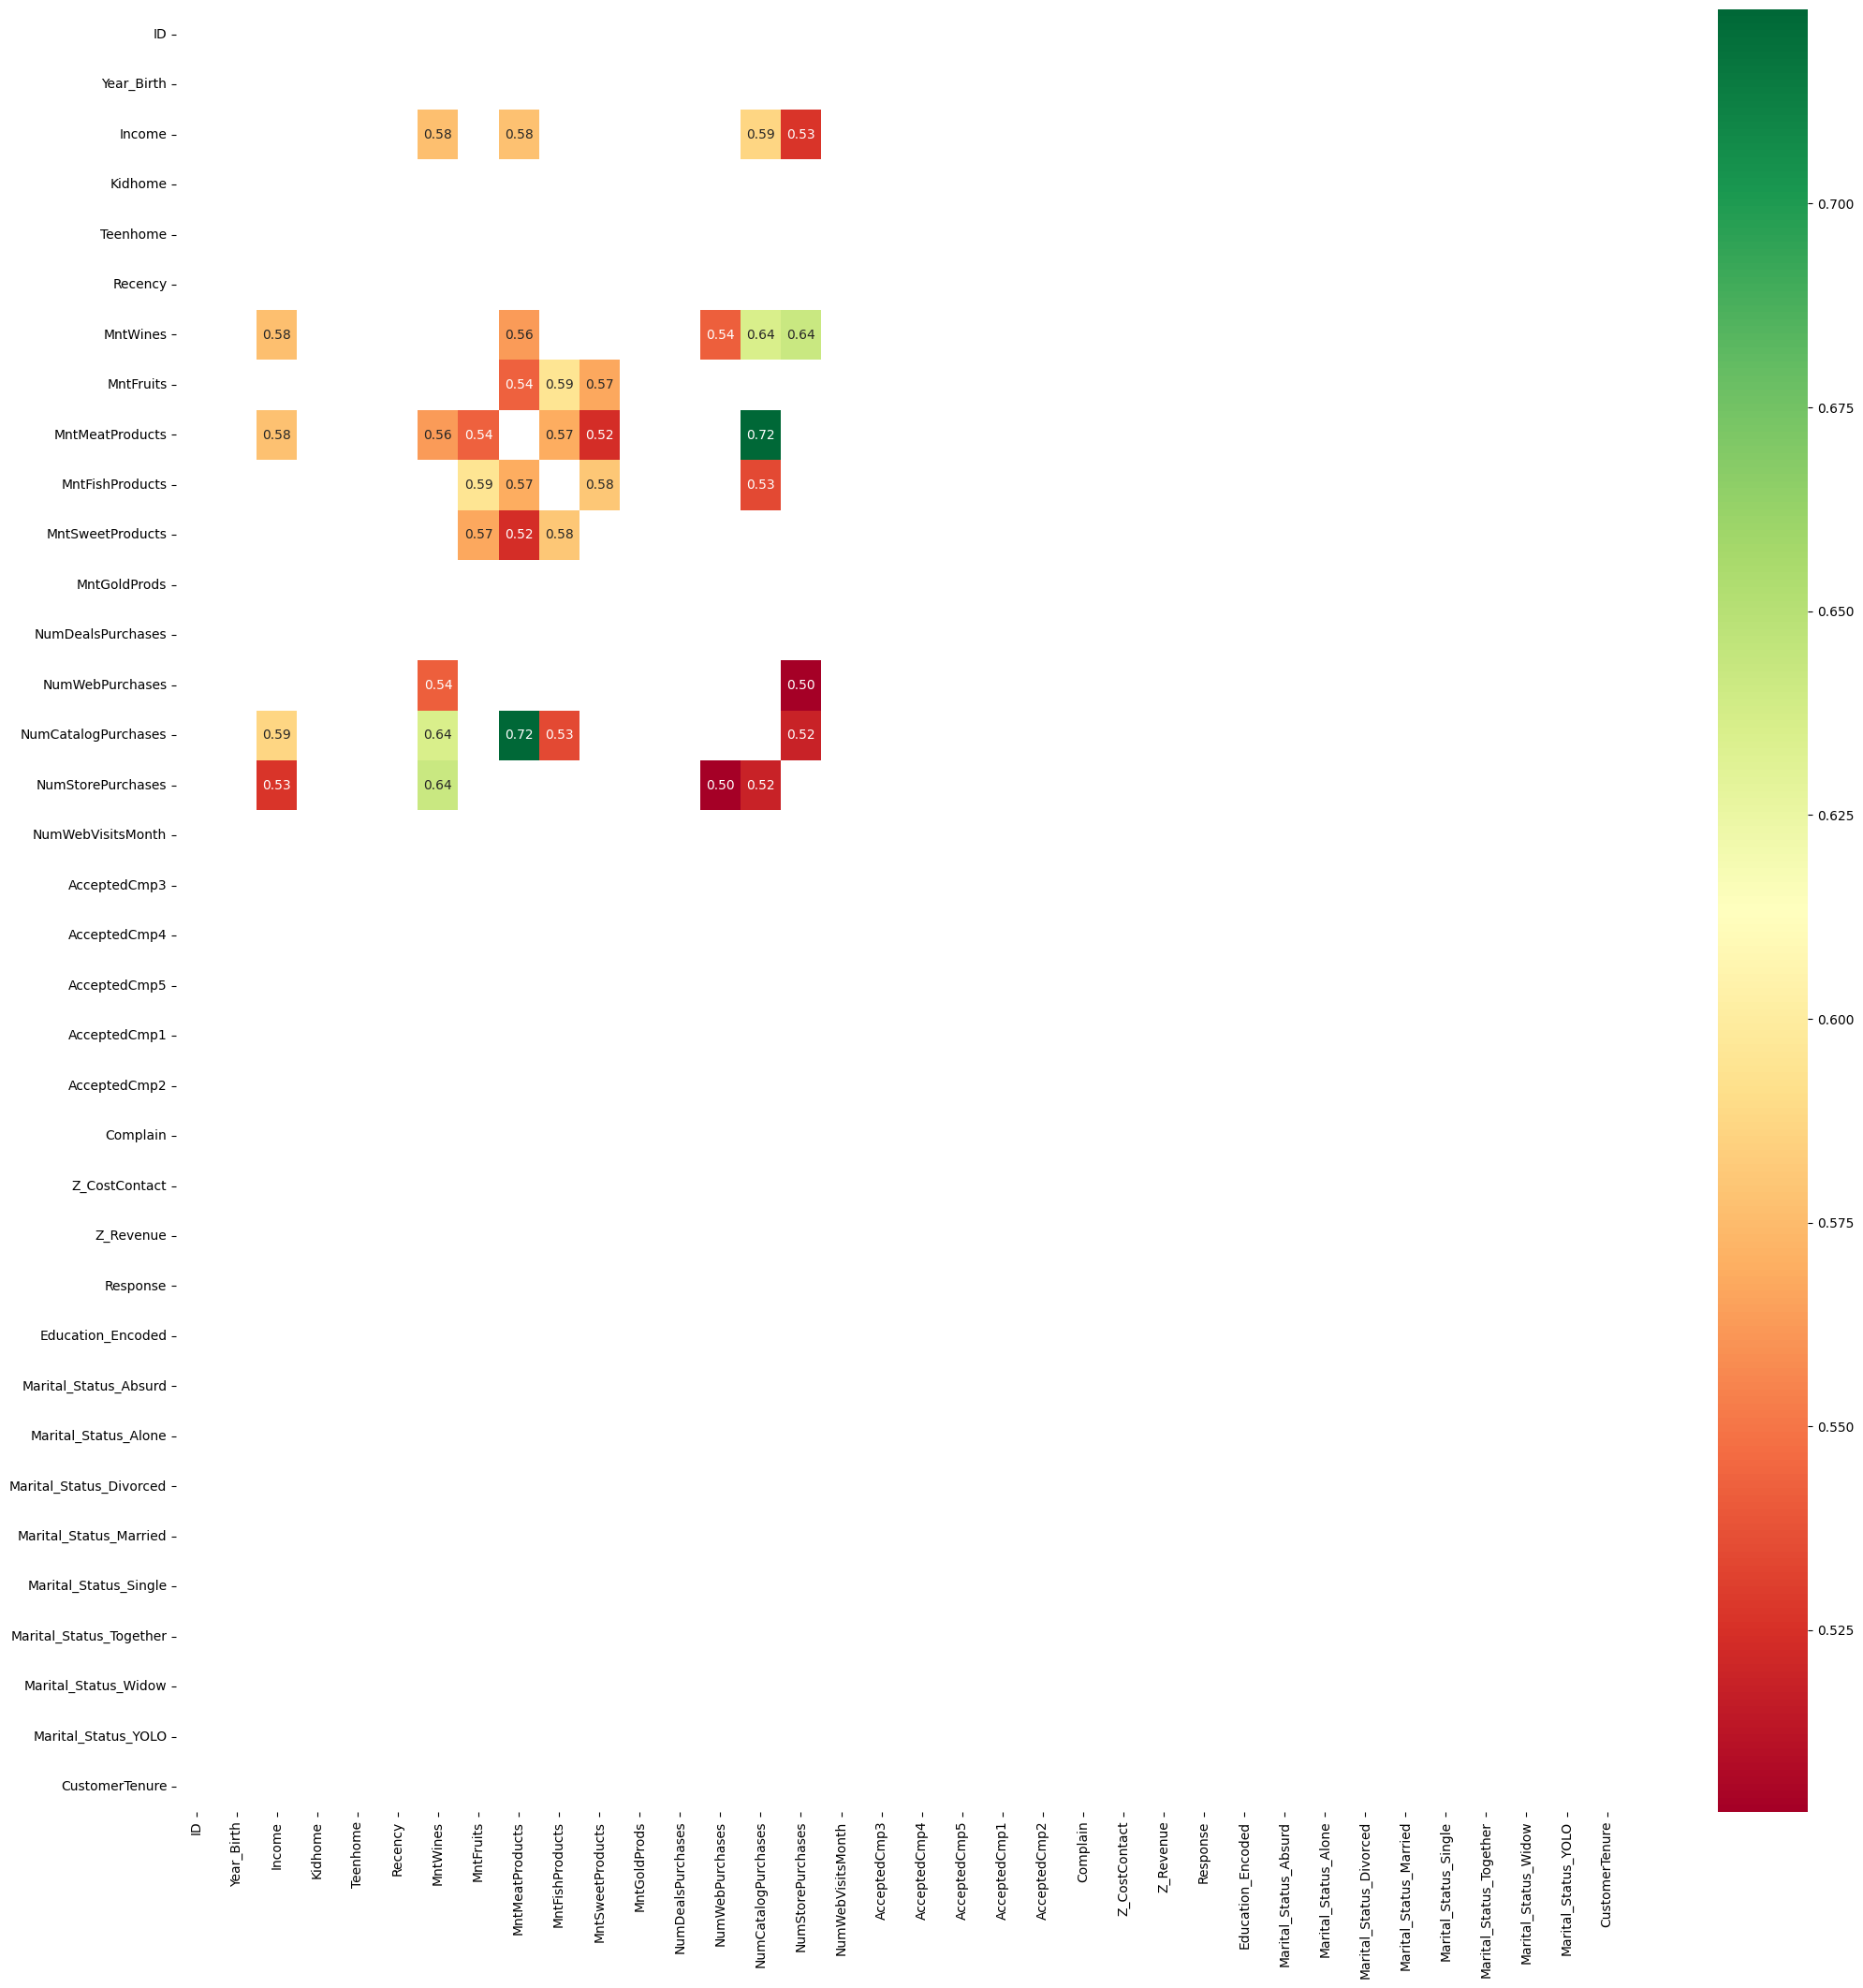

In [16]:
corr_df = df.select_dtypes(include=["int64","float64"]).corr()

plt.figure(figsize = (25,25))
sns.heatmap(data = corr_df[(corr_df >= 0.5) & (corr_df < 0.9999)], annot = True, cmap = "RdYlGn", cbar = True, fmt='.2f')
plt.show()

# **Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [17]:
df.columns

Index(['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Education_Encoded', 'Marital_Status_Absurd', 'Marital_Status_Alone',
       'Marital_Status_Divorced', 'Marital_Status_Married',
       'Marital_Status_Single', 'Marital_Status_Together',
       'Marital_Status_Widow', 'Marital_Status_YOLO', 'CustomerTenure',
       'YearJoined', 'MonthJoined'],
      dtype='object')

In [18]:
features = ['Year_Birth', 'Income', 'Kidhome',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth',
       'Education_Encoded', 'Marital_Status_Absurd', 'Marital_Status_Alone',
       'Marital_Status_Divorced', 'Marital_Status_Married',
       'Marital_Status_Single', 'Marital_Status_Together',
       'Marital_Status_Widow', 'Marital_Status_YOLO', 'CustomerTenure']
X = df[features]

In [19]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X)

labels = kmeans.predict(X)
print(labels)

[0 0 2 ... 0 2 0]


In [20]:
centroids = kmeans.cluster_centers_
s = metrics.silhouette_score(X, labels, metric='euclidean')
print(f'Silhouette Coefficient for the Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the Dataset Clusters: 0.54


#**Завдання 5.**
Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

In [21]:
import plotly.express as px

# Create an interactive 3D scatter plot
fig = px.scatter_3d(
    X,
    x='NumStorePurchases',
    y='Income',
    z='NumWebPurchases',
    #hover_data=['NumCatalogPurchases', 'NumWebPurchases', 'NumStorePurchases'],
    color=labels,
    title='3D Scatter Plot of Customer Personality Analysis Dataset'
)

# Show the figure
fig.show()

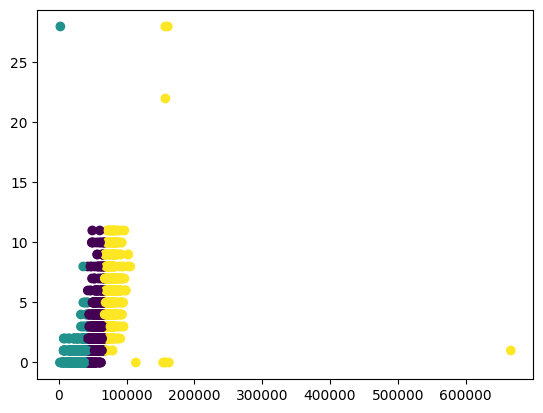

In [22]:
plt.scatter(X['Income'], X['NumCatalogPurchases'], c=labels)
plt.show()

**Завдання 6**. Масштабуйте дані і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [23]:
from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler to your data and transform it
scaled_data = scaler.fit_transform(X)

# Create a DataFrame from the scaled data with original column names
scaled_df = pd.DataFrame(scaled_data, columns=features, index=X.index)

X_s = scaled_df[features]

In [24]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X_s)

labels = kmeans.predict(X_s)
print(labels)

centroids = kmeans.cluster_centers_
s = metrics.silhouette_score(X_s, labels, metric='euclidean')
print(f'Silhouette Coefficient for the Dataset Clusters: {s:.2f}')

[2 0 1 ... 1 2 0]
Silhouette Coefficient for the Dataset Clusters: 0.15


Якість значно зросла після масштабування.

#**Завдання 7.**
З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [25]:
import numpy as np
import scipy.stats as stats

def find_columns_with_outliers_iqr(data):
    """
    Finds columns in a DataFrame that have outliers using the IQR method.

    Args:
        data: Pandas DataFrame.

    Returns:
        A list of column names with outliers.
    """
    columns_with_outliers = []
    for column in data.select_dtypes(include=np.number):  # Iterate over numerical columns
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        if data[(data[column] < lower_bound) | (data[column] > upper_bound)].any(axis=None):
            columns_with_outliers.append(column)
    return columns_with_outliers

# Example usage:
columns_with_outliers = find_columns_with_outliers_iqr(df)
print(f"Columns with outliers (IQR method): {columns_with_outliers}")

<ipython-input-25-af4406e27241>:21: FutureWarning:

'any' with datetime64 dtypes is deprecated and will raise in a future version. Use (obj != pd.Timestamp(0)).any() instead.

<ipython-input-25-af4406e27241>:21: FutureWarning:

'any' with datetime64 dtypes is deprecated and will raise in a future version. Use (obj != pd.Timestamp(0)).any() instead.

<ipython-input-25-af4406e27241>:21: FutureWarning:

'any' with datetime64 dtypes is deprecated and will raise in a future version. Use (obj != pd.Timestamp(0)).any() instead.

<ipython-input-25-af4406e27241>:21: FutureWarning:

'any' with datetime64 dtypes is deprecated and will raise in a future version. Use (obj != pd.Timestamp(0)).any() instead.

<ipython-input-25-af4406e27241>:21: FutureWarning:

'any' with datetime64 dtypes is deprecated and will raise in a future version. Use (obj != pd.Timestamp(0)).any() instead.

<ipython-input-25-af4406e27241>:21: FutureWarning:

'any' with datetime64 dtypes is deprecated and will raise in a futur

Columns with outliers (IQR method): ['Year_Birth', 'Income', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Education_Encoded', 'Marital_Status_Absurd', 'Marital_Status_Alone', 'Marital_Status_Divorced', 'Marital_Status_Single', 'Marital_Status_Widow', 'Marital_Status_YOLO', 'YearJoined']


<ipython-input-25-af4406e27241>:21: FutureWarning:

'any' with datetime64 dtypes is deprecated and will raise in a future version. Use (obj != pd.Timestamp(0)).any() instead.

<ipython-input-25-af4406e27241>:21: FutureWarning:

'any' with datetime64 dtypes is deprecated and will raise in a future version. Use (obj != pd.Timestamp(0)).any() instead.

<ipython-input-25-af4406e27241>:21: FutureWarning:

'any' with datetime64 dtypes is deprecated and will raise in a future version. Use (obj != pd.Timestamp(0)).any() instead.

<ipython-input-25-af4406e27241>:21: FutureWarning:

'any' with datetime64 dtypes is deprecated and will raise in a future version. Use (obj != pd.Timestamp(0)).any() instead.

<ipython-input-25-af4406e27241>:21: FutureWarning:

'any' with datetime64 dtypes is deprecated and will raise in a future version. Use (obj != pd.Timestamp(0)).any() instead.

<ipython-input-25-af4406e27241>:21: FutureWarning:

'any' with datetime64 dtypes is deprecated and will raise in a futur

In [26]:
out_features = ['Income', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumWebVisitsMonth', ]

In [27]:
df[out_features].describe()

,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumWebVisitsMonth
count,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00
mean,52237.98,303.94,26.30,166.95,37.53,27.06,44.02,2.33,4.08,2.66,5.32
std,25037.96,336.60,39.77,225.72,54.63,41.28,52.17,1.93,2.78,2.92,2.43
min,1730.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,35538.75,23.75,1.00,16.00,3.00,1.00,9.00,1.00,2.00,0.00,3.00
50%,51381.50,173.50,8.00,67.00,12.00,8.00,24.00,2.00,4.00,2.00,6.00
75%,68289.75,504.25,33.00,232.00,50.00,33.00,56.00,3.00,6.00,4.00,7.00
max,666666.00,1493.00,199.00,1725.00,259.00,263.00,362.00,15.00,27.00,28.00,20.00


In [28]:
def outlier_range(dataset,column):
    Q1 = dataset[column].quantile(0.25)
    Q3 = dataset[column].quantile(0.99)
    IQR = Q3 - Q1
    Min_value = (Q1 - 1.5 * IQR)
    Max_value = (Q3 + 1.5 * IQR)
    return print(Min_value, Max_value)

In [29]:
outlier_range(df, "Income")

-52809.64500000002 182786.075


Так як великі викиди є тільки в колонці Income, то видалимо їх. Інші можут містити інформативні дані.

In [30]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.95)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_filtered

# Initialize
df_filtered = df.copy()

# Remove outliers from specified columns
for column in ['Income']:
    df_filtered = remove_outliers_iqr(df_filtered, column)

df = df_filtered

In [31]:
# Fit the scaler to your data and transform it
scaled_data = scaler.fit_transform(df[['Income']]) # Reshape to 2D using double brackets

# Create a DataFrame from the scaled data with original column names
scaled_df = pd.DataFrame(scaled_data, columns=['Income'], index=df.index) # Correct column name

# Update the 'Income' column in your feature set
X_s['Income'] = scaled_df['Income'] # Assign scaled data to 'Income' column in X

In [32]:
X_s['Income'].fillna(X_s['Income'].median(), inplace=True)

<ipython-input-32-01d274e6a75d>:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





# **Завдання 8.**
Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

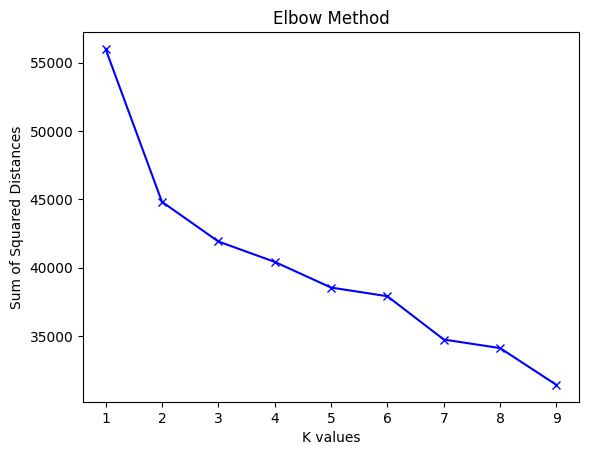

In [33]:
K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto').fit(X_s)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

In [34]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, n_init='auto')
kmeans.fit(X_s)

labels = kmeans.predict(X_s)
print(labels)

centroids = kmeans.cluster_centers_
s = metrics.silhouette_score(X_s, labels, metric='euclidean')
print(f'Silhouette Coefficient for the Dataset Clusters: {s:.2f}')

[0 1 0 ... 0 0 1]
Silhouette Coefficient for the Dataset Clusters: 0.22


In [37]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=7, n_init='auto')
kmeans.fit(X_s)

labels = kmeans.predict(X_s)
print(labels)

centroids = kmeans.cluster_centers_
s = metrics.silhouette_score(X_s, labels, metric='euclidean')
print(f'Silhouette Coefficient for the Dataset Clusters: {s:.2f}')

[0 2 5 ... 5 5 1]
Silhouette Coefficient for the Dataset Clusters: 0.09


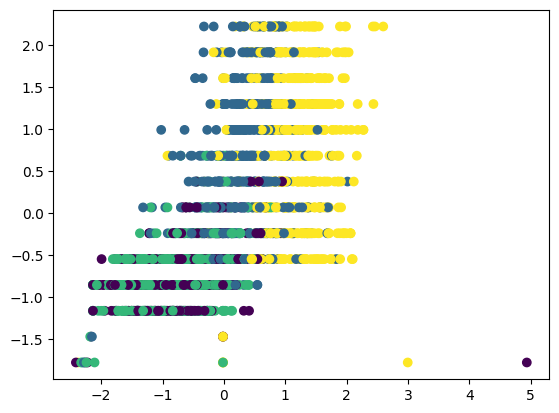

In [36]:
plt.scatter(X_s['Income'], X_s['NumStorePurchases'], c=labels)
plt.show()

# **Завдання 9.**
Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

In [38]:
X = df[features]

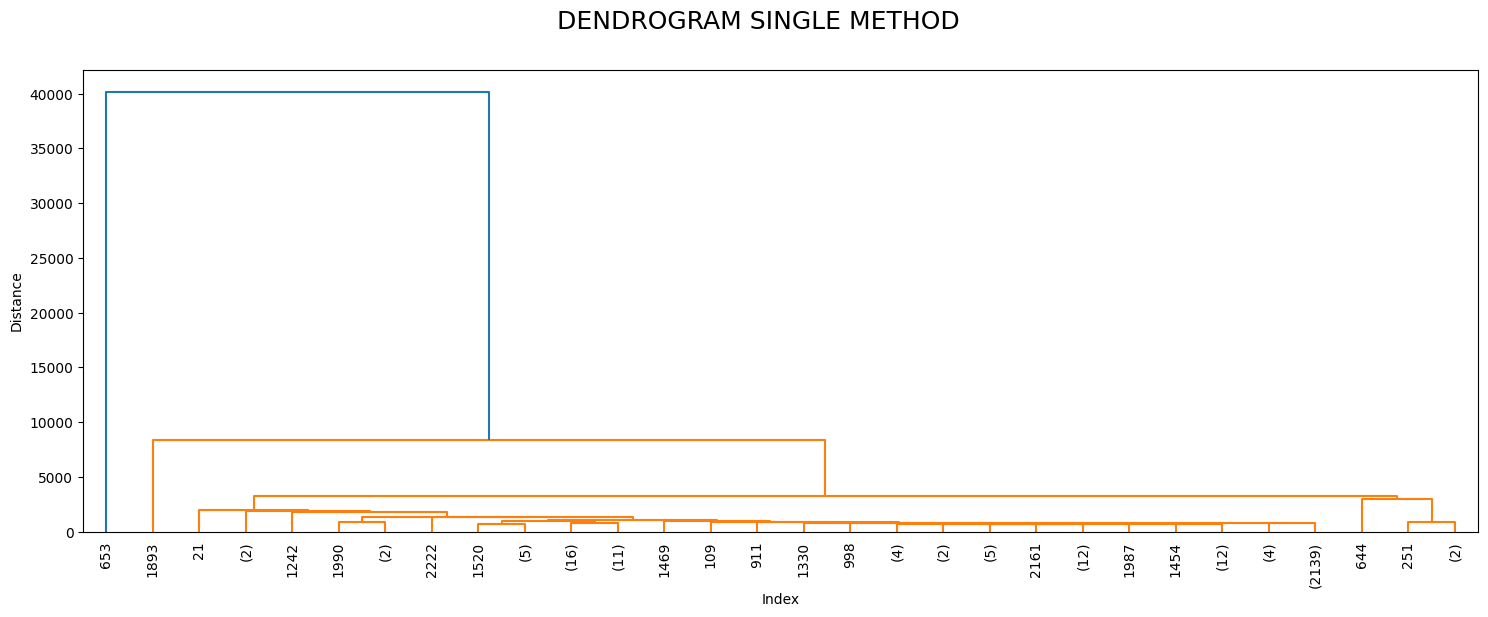

In [83]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

dist_sin = linkage(X, method="single")
plt.figure(figsize=(18,6))
dendrogram(dist_sin, leaf_rotation=90, truncate_mode='lastp')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("DENDROGRAM SINGLE METHOD",fontsize=18)
plt.show()

In [84]:
X['2_clust'] = fcluster(dist_sin, 2, criterion='maxclust')
X['3_clust'] = fcluster(dist_sin, 3, criterion='maxclust')

<ipython-input-84-b784f1f380fe>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-84-b784f1f380fe>:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [50]:
from sklearn.metrics import silhouette_score

# Get cluster labels using fcluster
labels = X['2_clust']

# Calculate Silhouette Score
s = silhouette_score(X, labels, metric='euclidean')
print(f'Silhouette Coefficient for Single Linkage Clustering: {s:.2f}')

Silhouette Coefficient for Single Linkage Clustering: 0.75


In [51]:
from sklearn.metrics import silhouette_score

# Get cluster labels using fcluster
labels = X['3_clust']

# Calculate Silhouette Score
s = silhouette_score(X, labels, metric='euclidean')
print(f'Silhouette Coefficient for Single Linkage Clustering: {s:.2f}')

Silhouette Coefficient for Single Linkage Clustering: 0.56


<Axes: title={'center': 'K = 3'}, xlabel='NumWebPurchases', ylabel='Income'>

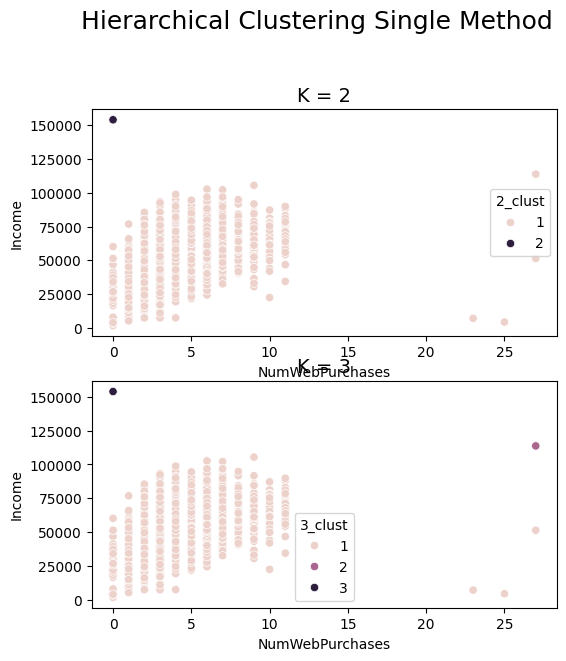

In [88]:
import seaborn as sns

plt.figure(figsize=(6,10))

plt.suptitle("Hierarchical Clustering Single Method",fontsize=18)

plt.subplot(3,1,1)
plt.title("K = 2",fontsize=14)
sns.scatterplot(x="NumWebPurchases",y="Income", data=df, hue="2_clust")

plt.subplot(3,1,2)
plt.title("K = 3",fontsize=14)
sns.scatterplot(x="NumWebPurchases",y="Income", data=df, hue="3_clust")


У ієрархічній агломеративній кластеризації з single linkage найкращий скор по силуету з 3 кластерами. Але на графіках можно побачити, що дані не кластеризуються нормально. З іншими комбінаціями колонок така ж ситуація. Можна побачити единичні кластери з залишками. Залишки залишила, бо зростав силует через видалення всіх залишків.

# **Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

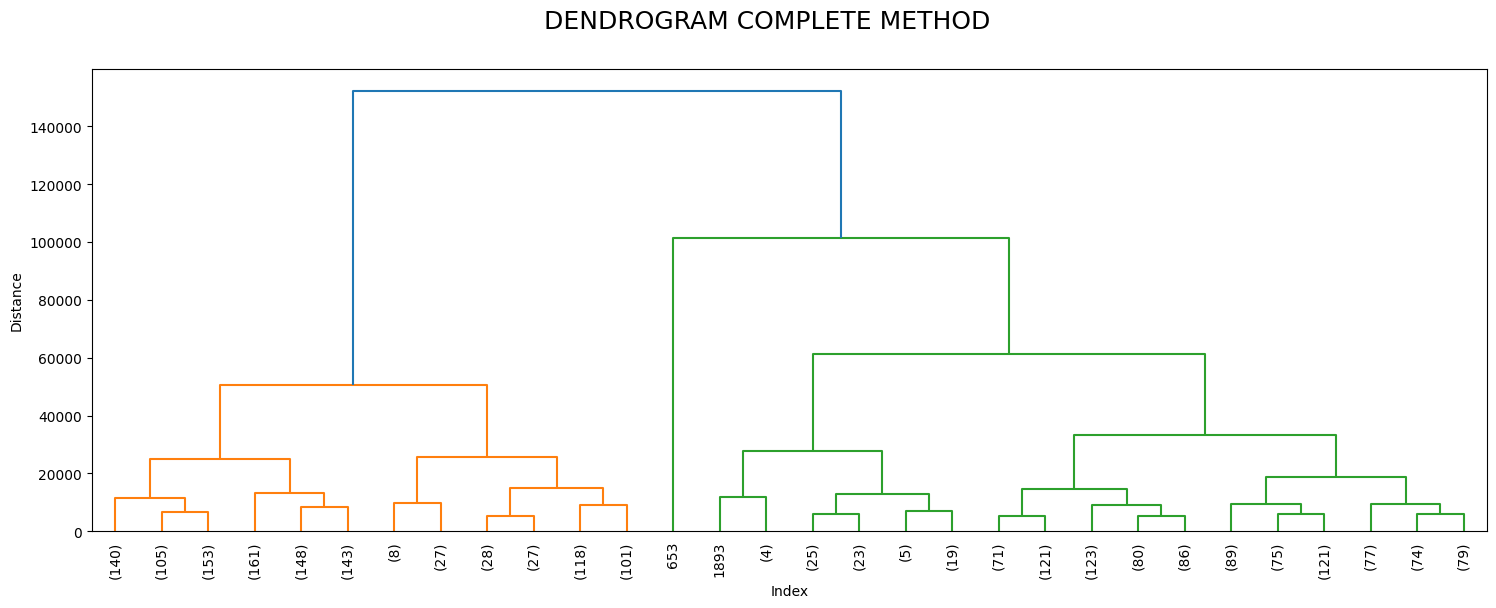

In [99]:
dist_comp = linkage(X, method="complete")

plt.figure(figsize=(18,6))
dendrogram(dist_comp, leaf_rotation=90, truncate_mode='lastp')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("DENDROGRAM COMPLETE METHOD",fontsize=18)
plt.show()

In [100]:
df['2_clust_CM']=fcluster(dist_comp, 2, criterion='maxclust')
df['3_clust_CM']=fcluster(dist_comp, 3, criterion='maxclust')
df.head()

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,CustomerTenure,YearJoined,MonthJoined,2_clust,3_clust,2_clust_CM,3_clust_CM
0,5524,1957,58138.00,0,0,2012-09-04,58,635,88,546,...,0.00,0.00,0.00,4600,2012,9,1,1,2,2
1,2174,1954,46344.00,1,1,2014-03-08,38,11,1,6,...,0.00,0.00,0.00,4050,2014,3,1,1,1,1
2,4141,1965,71613.00,0,0,2013-08-21,26,426,49,127,...,1.00,0.00,0.00,4249,2013,8,1,1,2,2
3,6182,1984,26646.00,1,0,2014-02-10,26,11,4,20,...,1.00,0.00,0.00,4076,2014,2,1,1,1,1
4,5324,1981,58293.00,1,0,2014-01-19,94,173,43,118,...,0.00,0.00,0.00,4098,2014,1,1,1,2,2


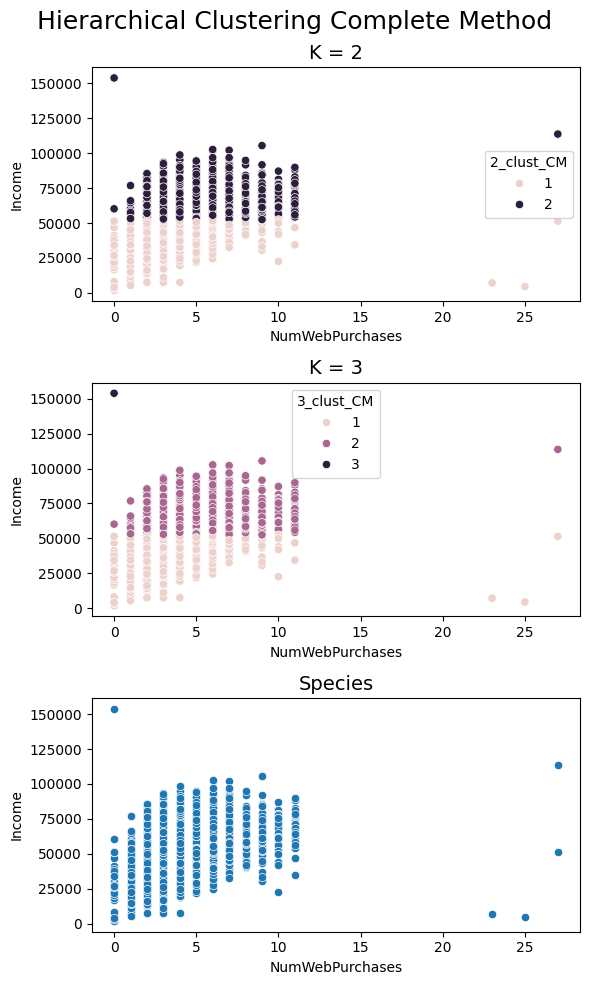

In [101]:
plt.figure(figsize=(6,10))

plt.suptitle("Hierarchical Clustering Complete Method",fontsize=18)

plt.subplot(3,1,1)
plt.title("K = 2",fontsize=14)
sns.scatterplot(x="NumWebPurchases",y="Income", data=df, hue="2_clust_CM")

plt.subplot(3,1,2)
plt.title("K = 3",fontsize=14)
sns.scatterplot(x="NumWebPurchases",y="Income", data=df, hue="3_clust_CM")

plt.subplot(3,1,3)
plt.title("Species",fontsize=14)
sns.scatterplot(x="NumWebPurchases",y="Income", data=df)
plt.tight_layout();

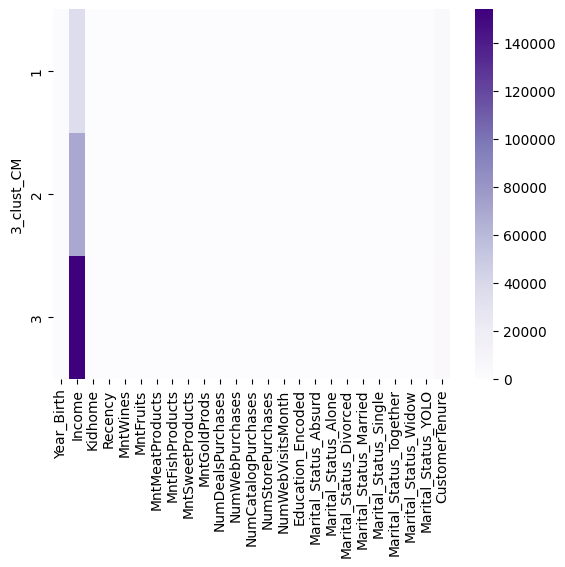

In [108]:
filter_col_names = features + ['3_clust_CM']
sns.heatmap(df[filter_col_names].groupby(['3_clust_CM']).mean(), cmap="Purples");

У ієрархічній агломеративній кластеризації з Complete Method 3 кластери показують розділення по прибутку, що є досить логічним: є клієнти з низьким, середнім та високим прибутком.

Цей метод спрацював найкраще по кластеризації клієнтів. Але потрібно ще експерементувати з вибором фіч.